In [1]:
import os, numpy as np, pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# kalau kamu pakai seaborn
import seaborn as sns

In [5]:
import os
from PIL import Image
from tqdm import tqdm
import pandas as pd

# --- KHUSUS HEIC ---
# Daftarkan pembaca HEIC agar Image.open() bisa membacanya
try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
    print("Support HEIC berhasil diaktifkan.")
except ImportError:
    print("Library 'pillow-heif' belum terinstall. Jalankan '!pip install pillow-heif' dulu.")

# ==========================================
# KONVERSI SEMUA DATA (TERMASUK HEIC) KE PNG
# ==========================================

output_base_dir = 'Dataset New EF'  # Folder tujuan
print(f"\nMemulai konversi gambar ke PNG...")
print(f"Data akan disimpan di: {output_base_dir}")

new_data_list = []
error_files = []

# Menggunakan tqdm untuk progress bar
for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Converting"):
    src_path = row['filepath']
    label = row['label']  
    
    # 1. Persiapan Folder Tujuan
    parts = label.split() 
    variation_folder = parts[0] # V1
    quality_folder = parts[1]   # GOOD
    
    target_folder = os.path.join(output_base_dir, quality_folder, variation_folder)
    os.makedirs(target_folder, exist_ok=True)
    
    # 2. Nama File Baru (.png)
    file_name = os.path.basename(src_path)
    name_without_ext = os.path.splitext(file_name)[0]
    new_filename = f"{name_without_ext}.png"
    dst_path = os.path.join(target_folder, new_filename)
    
    # 3. Proses Konversi
    try:
        # Image.open sekarang sudah bisa buka HEIC karena register_heif_opener()
        with Image.open(src_path) as img:
            
            # Convert ke RGB 
            # (Penting: HEIC/PNG bisa punya alpha channel/transparansi, 
            # untuk deep learning amannya dipaksa ke RGB 3-channel)
            img = img.convert('RGB')
            
            # Simpan sebagai PNG
            img.save(dst_path, 'PNG')
            
            # Masukkan path baru ke list
            new_data_list.append({'filepath': dst_path, 'label': label})
            
    except Exception as e:
        print(f"\n[ERROR] Gagal: {src_path} | Error: {e}")
        error_files.append(src_path)

# ==========================================
# UPDATE DATAFRAME
# ==========================================
df_png = pd.DataFrame(new_data_list)
df = df_png # Timpa df lama dengan data PNG baru

print("\n" + "="*40)
print("KONVERSI SELESAI")
print("="*40)
print(f"Total Asli  : {len(df) + len(error_files)}")
print(f"Berhasil PNG: {len(df_png)}")
print(f"Gagal       : {len(error_files)}")

if len(error_files) > 0:
    print("Contoh file gagal:", error_files[:3])

Support HEIC berhasil diaktifkan.

Memulai konversi gambar ke PNG...
Data akan disimpan di: Dataset New EF


Converting: 100%|██████████| 80/80 [00:23<00:00,  3.40it/s]


KONVERSI SELESAI
Total Asli  : 80
Berhasil PNG: 80
Gagal       : 0


In [46]:
# ==========================================
# 1. MOUNT GOOGLE DRIVE & PERSIAPAN DATA
# ==========================================


# --- KONFIGURASI FOLDER ---
# Pastikan path ini sesuai dengan di Drive Anda
base_dir = 'Dataset New EF'

# List Variasi dan Kualitas sesuai struktur folder Anda
qualities = ['GOOD', "BAD"]
# qualities = ['GOOD']
variations = ['V1', 'V2', 'V3', 'V4']
print("Sedang memindai file dan membuat label...")

data_list = []

# Loop untuk membaca file dari struktur folder
for quality in qualities:

  for variation in variations:
      # Menyusun path: .../TANPA LEMPUK/GOOD/Variasi 1
      folder_path = os.path.join(base_dir, quality, variation)
        
      if os.path.exists(folder_path):
          files = os.listdir(folder_path)
          for file_name in files:
              if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                  # Membuat Label: "Variasi 1 GOOD", dst.
                  label_name = f"{variation} {quality}" 
                  full_path = os.path.join(folder_path, file_name)
                  data_list.append({'filepath': full_path, 'label': label_name})
      else:
          print(f"Warning: Folder tidak ditemukan -> {folder_path}")

# Konversi ke DataFrame
df = pd.DataFrame(data_list)
print(f"\nTotal Data Ditemukan: {len(df)}")
print(f"Jumlah Kelas: {df['label'].nunique()}")

# Cek distribusi data
print("\nJumlah data per kelas:")
print(df['label'].value_counts())

# urutan kelas yang kamu mau
class_names = [f"{v} {q}" for v in variations for q in qualities]

Sedang memindai file dan membuat label...

Total Data Ditemukan: 80
Jumlah Kelas: 8

Jumlah data per kelas:
label
V1 GOOD    10
V2 GOOD    10
V3 GOOD    10
V4 GOOD    10
V1 BAD     10
V2 BAD     10
V3 BAD     10
V4 BAD     10
Name: count, dtype: int64


In [47]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = (150, 150)  # samakan dengan training kamu
BATCH_SIZE = 32

# preprocessing: sesuaikan dengan backbone kamu saat training
# DenseNet biasanya pakai preprocess_input dari tf.keras.applications.densenet
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",  # ✅ harus string
    classes=class_names, 
    shuffle=False
)

    
print(class_names)

Found 80 validated image filenames belonging to 8 classes.
['V1 GOOD', 'V1 BAD', 'V2 GOOD', 'V2 BAD', 'V3 GOOD', 'V3 BAD', 'V4 GOOD', 'V4 BAD']


In [50]:
import tensorflow as tf

MODEL_PATH = "Exp1_DenseNet121_Dengan_Lempuk_final_model.keras"
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded:", MODEL_PATH)

Model loaded: Exp1_DenseNet121_Dengan_Lempuk_final_model.keras


2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/stepWARNING:tensorflow:5 out of the last 16 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001AA9D5155E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
              precision    recall  f1-score   support

     V1 GOOD     1.0000    0.3000    0.4615        10
      V1 BAD     0.7778    0.7000    0.7368        10
     V2 GOOD     0.6667    0.2000   

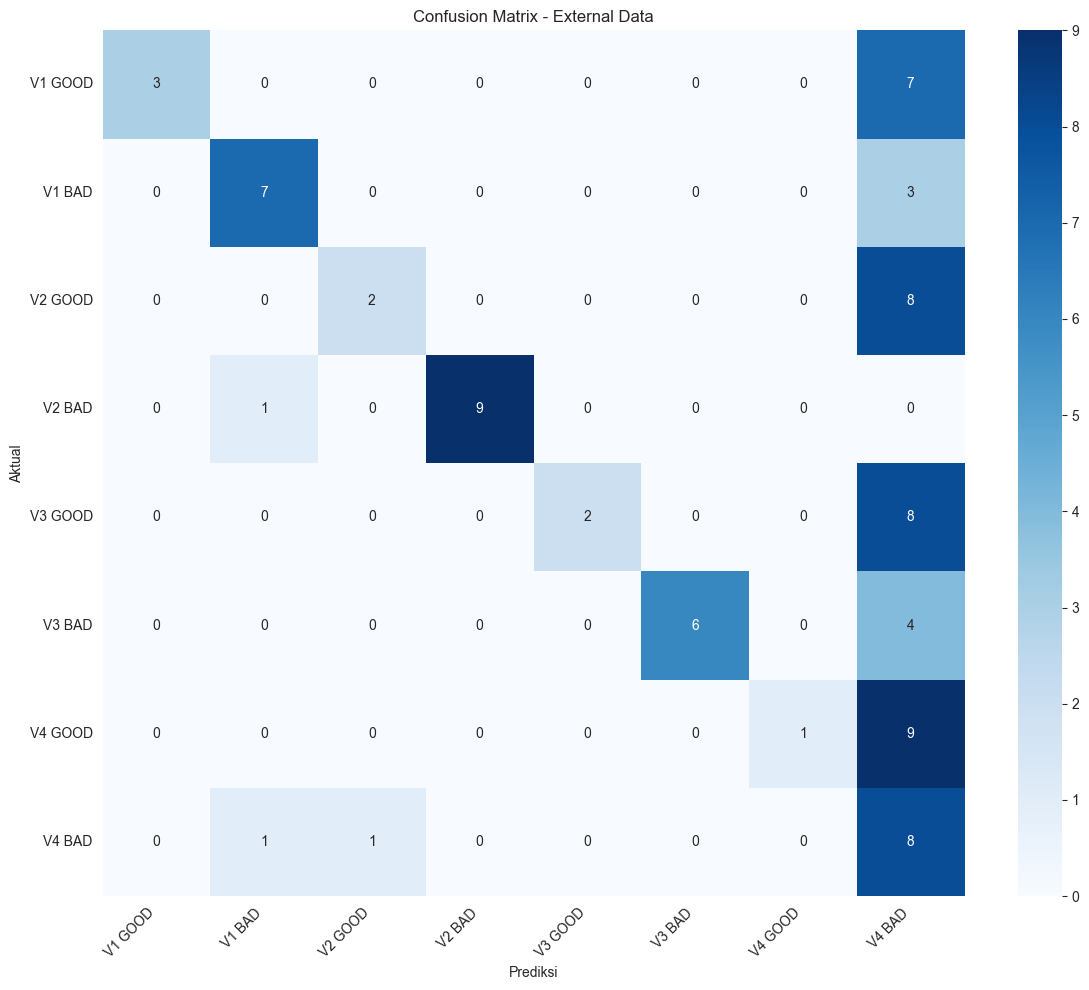

In [51]:
# prediksi
pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes  # sudah sesuai urutan data karena shuffle=False

# report
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix - External Data")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()